In [1]:
import pandas as pd
import matplotlib.pyplot as plt

https://data.mendeley.com/datasets/574v66hf2v/1

# Collecting data

In [2]:
df = pd.read_csv("../datasets/PRDECT-ID Dataset.csv")
df.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


In [3]:
print(f"Total rows: {len(df)}")
print(f"Total duplicates: {df.duplicated().sum()}")
print("\nMissing values per column:")
print(df.isnull().sum())

Total rows: 5400
Total duplicates: 7

Missing values per column:
Category           0
Product Name       0
Location           0
Price              0
Overall Rating     0
Number Sold        0
Total Review       0
Customer Rating    0
Customer Review    0
Sentiment          0
Emotion            0
dtype: int64


In [4]:
df.drop_duplicates(inplace=True)

# SPLITTING DATASET

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
strat_train_set, strat_test_set = train_test_split(df, test_size=0.2, 
random_state=42, stratify=df["Category"])

In [7]:
print("stratified test set")
print(strat_test_set["Category"].value_counts() / len(strat_test_set))


stratified test set
Category
Body Care                   0.037071
Household                   0.037071
Movies and Music            0.037071
Sport                       0.037071
Food and Drink              0.037071
Animal Care                 0.037071
Other Products              0.037071
Carpentry                   0.037071
Mother and Baby             0.037071
Men's Fashion               0.037071
Health                      0.037071
Books                       0.037071
Phones and Tablets          0.037071
Women's Fashion             0.037071
Kitchen                     0.037071
Office & Stationery         0.037071
Beauty                      0.037071
Kids and Baby Fashion       0.037071
Automotive                  0.037071
Electronics                 0.037071
Gaming                      0.037071
Toys and Hobbies            0.037071
Party Supplies and Craft    0.037071
Muslim Fashion              0.037071
Camera                      0.037071
Computers and Laptops       0.036145
Precious 

In [8]:
print(strat_test_set["Category"].value_counts() / len(strat_test_set))

Category
Body Care                   0.037071
Household                   0.037071
Movies and Music            0.037071
Sport                       0.037071
Food and Drink              0.037071
Animal Care                 0.037071
Other Products              0.037071
Carpentry                   0.037071
Mother and Baby             0.037071
Men's Fashion               0.037071
Health                      0.037071
Books                       0.037071
Phones and Tablets          0.037071
Women's Fashion             0.037071
Kitchen                     0.037071
Office & Stationery         0.037071
Beauty                      0.037071
Kids and Baby Fashion       0.037071
Automotive                  0.037071
Electronics                 0.037071
Gaming                      0.037071
Toys and Hobbies            0.037071
Party Supplies and Craft    0.037071
Muslim Fashion              0.037071
Camera                      0.037071
Computers and Laptops       0.036145
Precious Metal              0

# EDA

In [9]:
import copy

In [10]:
df_eda = copy.deepcopy(strat_train_set)

In [11]:
df_eda.describe()

,Price,Overall Rating,Number Sold,Total Review,Customer Rating
count,4.314000e+03,4314.000000,4314.000000,4314.000000,4314.000000
mean,2.409008e+05,4.854891,16174.674316,2166.344924,3.093649
std,7.839477e+05,0.108252,75769.168613,2920.731847,1.765801
min,1.000000e+02,4.100000,14.000000,6.000000,1.000000
25%,2.000000e+04,4.800000,1565.000000,574.000000,1.000000
50%,5.990000e+04,4.900000,3772.000000,1188.000000,3.000000
75%,1.500000e+05,4.900000,9852.000000,2590.250000,5.000000
max,9.710000e+06,5.000000,1000000.000000,24500.000000,5.000000


array([[<Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Overall Rating'}>],
       [<Axes: title={'center': 'Number Sold'}>, <Axes: >]], dtype=object)

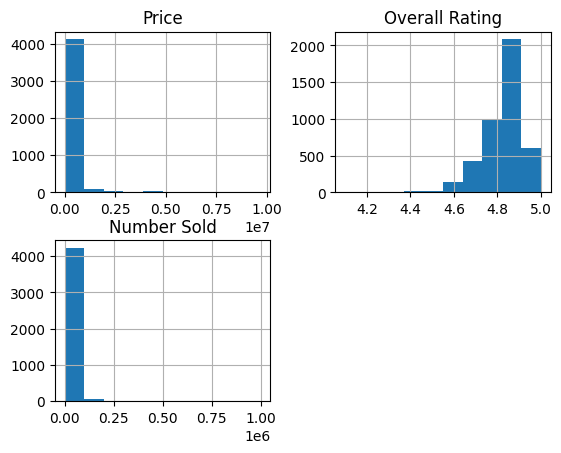

In [12]:
df_eda.hist(column=["Price", "Overall Rating", "Number Sold"])

Price dan Number Sold memiliki skewness

In [13]:
corr_matrix = df_eda.corr(numeric_only=True)

In [14]:
corr_matrix["Number Sold"].sort_values(ascending=False)

Number Sold        1.000000
Total Review       0.162090
Overall Rating     0.013213
Price             -0.049439
Customer Rating   -0.060043
Name: Number Sold, dtype: float64

rata-rata rating (Overall Rating) memiliki korelasi dengan Number Sold. 
Begitupun dengan price, meskipun negatif korelasinya, artinya semakin kecil Price 
semakin banyak pembelinya.

<Axes: xlabel='Overall Rating', ylabel='Number Sold'>

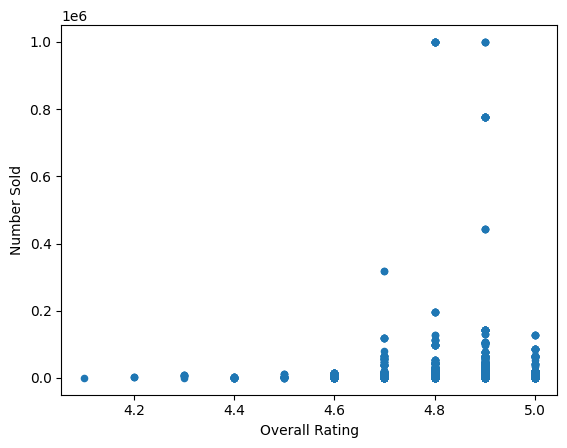

In [15]:
df_eda.plot(kind="scatter", x="Overall Rating", y="Number Sold")

<Axes: xlabel='Price', ylabel='Number Sold'>

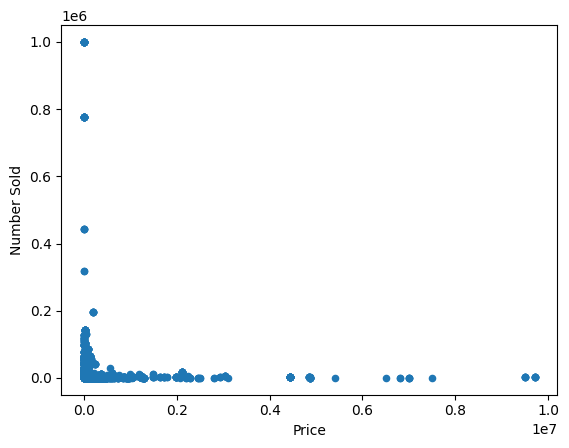

In [16]:
df_eda.plot(kind="scatter", x="Price", y="Number Sold")

# Data Pre-Processing

In [17]:
print(strat_train_set.columns)

Index(['Category', 'Product Name', 'Location', 'Price', 'Overall Rating',
       'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review',
       'Sentiment', 'Emotion'],
      dtype='str')


In [18]:
df = copy.deepcopy(strat_train_set)
df = df.drop(strat_train_set.columns[1:3], axis=1)
df = df.drop(strat_train_set.columns[6:], axis=1)


In [19]:
df.head()

,Category,Price,Overall Rating,Number Sold
1775,Carpentry,3700,4.8,112600
3847,Household,6385,4.7,120294
5044,Camera,245000,4.9,4652
57,Computers and Laptops,90000,4.8,4563
3399,Phones and Tablets,98500,4.9,5529


In [20]:
strat_test_set = strat_test_set.drop(strat_test_set.columns[1:3], axis=1)
strat_test_set = strat_test_set.drop(strat_test_set.columns[6:], axis=1)
strat_test_set = strat_test_set.drop(["Total Review", "Customer Rating"], axis=1)

In [21]:
strat_test_set.head()

,Category,Price,Overall Rating,Number Sold
1301,Body Care,250000,4.9,40300
1240,Body Care,128600,4.9,2501
5338,Household,44900,4.8,9933
4678,Movies and Music,10000,4.8,2461
2151,Sport,16200,4.9,6323


In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 4314 entries, 1775 to 4941
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        4314 non-null   str    
 1   Price           4314 non-null   int64  
 2   Overall Rating  4314 non-null   float64
 3   Number Sold     4314 non-null   int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 168.5 KB


In [23]:
display(df.isnull().sum())


Category          0
Price             0
Overall Rating    0
Number Sold       0
dtype: int64

<Axes: >

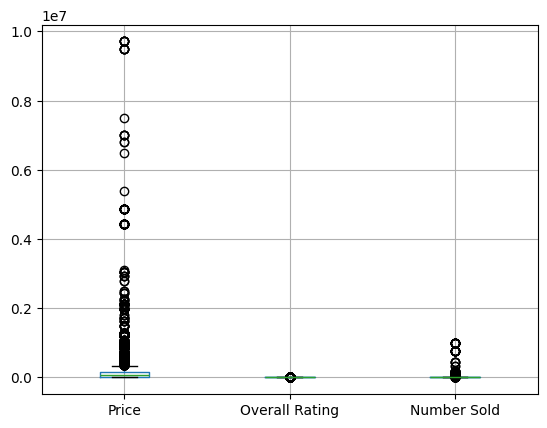

In [24]:
df.boxplot()

In [25]:
from sklearn.preprocessing import PowerTransformer

In [26]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ('num',  PowerTransformer(standardize=True), ["Price", "Overall Rating"]),    
    ('cat',    OneHotEncoder(sparse_output=False), ["Category"]),
], remainder='passthrough', verbose_feature_names_out=False)



In [27]:
df_labels = df["Number Sold"]
df = df.drop(columns=["Number Sold"])

In [28]:
df.head()

,Category,Price,Overall Rating
1775,Carpentry,3700,4.8
3847,Household,6385,4.7
5044,Camera,245000,4.9
57,Computers and Laptops,90000,4.8
3399,Phones and Tablets,98500,4.9


In [29]:
df_labels.head()

1775    112600
3847    120294
5044      4652
57        4563
3399      5529
Name: Number Sold, dtype: int64

# Training

**Linear Regression**

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import make_pipeline



In [31]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(
    preprocessor,
    TransformedTargetRegressor(
        regressor=LinearRegression(),
        transformer=PowerTransformer()
    )
)
lin_reg.fit(df, df_labels)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('transformedtargetregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

In [32]:
pred = lin_reg.predict(df)
print(pred[:5])
print()
print( df_labels[:5])

[18752.17166861  7848.52551486  1742.29390575  4659.96543923
  8002.15522939]

1775    112600
3847    120294
5044      4652
57        4563
3399      5529
Name: Number Sold, dtype: int64


In [33]:
lin_reg_rmse = root_mean_squared_error(df_labels, pred)
lin_reg_rmse

71755.898207254

In [34]:
from sklearn.model_selection import cross_val_score

lin_reg_rmses = cross_val_score(lin_reg, df, df_labels, 
                             scoring="neg_root_mean_squared_error", cv=10)
pd.Series(-lin_reg_rmses).describe()

count        10.000000
mean      69480.115771
std       19052.289661
min       45496.253658
25%       61173.417161
50%       65526.012473
75%       71983.412724
max      109260.598770
dtype: float64

**DECISION TREE**

In [35]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline
tree_reg = make_pipeline(preprocessor, DecisionTreeRegressor(random_state=42))
tree_reg.fit(df, df_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of t

In [36]:
pred = tree_reg.predict(df)
print(pred[:5])

[112600. 120294.   4652.   4563.   5529.]


In [37]:
tree_rmse = root_mean_squared_error(df_labels, pred)
tree_rmse

3042.6146611063336

In [38]:

tree_rmses = cross_val_score(tree_reg, df, df_labels, 
                             scoring="neg_root_mean_squared_error", cv=10)
pd.Series(-tree_rmses).describe()

count       10.000000
mean     14619.295108
std      14828.467381
min       4405.438259
25%       5226.382504
50%       8244.606075
75%      14434.468853
max      47912.874516
dtype: float64

**Random Forrest**

In [39]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessor, RandomForestRegressor(random_state=42))

In [40]:
forest_rmses = -cross_val_score(forest_reg, df, df_labels, 
                                scoring="neg_root_mean_squared_error", cv=10)
pd.Series(forest_rmses).describe()

count       10.000000
mean     13712.193343
std      14363.437032
min       4561.039987
25%       5087.964012
50%       8253.524235
75%      10418.461689
max      45246.558705
dtype: float64

# Fine Tuning

**Grid Seach**

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [42]:
full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("random_forest", RandomForestRegressor(random_state=42))
])

In [43]:
param_grid = [
    {
      'random_forest__max_features': ['sqrt', 'log2', 0.3, 0.5, None]    
    }
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
scoring='neg_root_mean_squared_error')

In [44]:
grid_search.fit(df, df_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'random_forest__max_features': ['sqrt', 'log2', ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [45]:
grid_search.best_params_

{'random_forest__max_features': 'log2'}

In [46]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
1,0.633830,0.087484,0.057132,0.002747,log2,{'random_forest__max_features': 'log2'},-12991.267522,-30502.949926,-5921.444613,-16471.887354,10332.751704,1
2,0.711422,0.007885,0.054141,0.000770,0.3,{'random_forest__max_features': 0.3},-13875.059956,-29851.310551,-5699.296675,-16475.222394,10029.974314,2
4,1.329042,0.029515,0.057639,0.002946,None,{'random_forest__max_features': None},-21990.776077,-22361.421488,-5746.471201,-16699.556256,7746.478712,3
3,0.829757,0.014233,0.056044,0.003205,0.5,{'random_forest__max_features': 0.5},-14271.459823,-30051.109031,-5827.312011,-16716.626955,10039.329899,4
0,0.628216,0.017973,0.059478,0.002303,sqrt,{'random_forest__max_features': 'sqrt'},-14551.394465,-30275.940804,-6101.935802,-16976.423690,10016.859272,5


**Randomized Search**

In [47]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
'random_forest__max_features': randint(low=2, high=20)}
rnd_search = RandomizedSearchCV(
full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
scoring='neg_root_mean_squared_error', random_state=42)
rnd_search.fit(df, df_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'random_forest__max_features': <scipy.stats....001F2E6E9BE00>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if

In [48]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
1,0.826184,0.027144,0.071741,0.026201,16,{'random_forest__max_features': 16},-13934.993914,-28498.081306,-5624.115433,-16019.063551,9453.820687,1
0,0.658550,0.008263,0.060098,0.004563,8,{'random_forest__max_features': 8},-13609.379321,-29522.148771,-5721.736044,-16284.421379,9898.882058,2
4,0.664804,0.049641,0.056755,0.003454,8,{'random_forest__max_features': 8},-13609.379321,-29522.148771,-5721.736044,-16284.421379,9898.882058,2
9,0.535532,0.009571,0.057350,0.002385,4,{'random_forest__max_features': 4},-12991.267522,-30502.949926,-5921.444613,-16471.887354,10332.751704,4
8,0.666042,0.020117,0.057491,0.001099,9,{'random_forest__max_features': 9},-13875.059956,-29851.310551,-5699.296675,-16475.222394,10029.974314,5


In [49]:
final_model = rnd_search.best_estimator_

In [50]:
pred = final_model.predict(df)
print(pred[:5])
print()
print(df_labels[:5])

[112600.         120294.           4545.54316667   4563.
   5541.05      ]

1775    112600
3847    120294
5044      4652
57        4563
3399      5529
Name: Number Sold, dtype: int64


In [51]:
final_model_rmses = -cross_val_score(final_model, df, df_labels, 
                                scoring="neg_root_mean_squared_error", cv=10)
pd.Series(final_model_rmses).describe()

count       10.000000
mean     11800.706460
std      10794.803295
min       4330.546094
25%       5238.898915
50%       7099.459874
75%      10402.984228
max      35578.686351
dtype: float64

# Evaluate

In [52]:
X_test = strat_test_set.drop("Number Sold", axis=1)
y_test = copy.copy(strat_test_set.iloc[:, -1])

In [53]:
X_test.head()


,Category,Price,Overall Rating
1301,Body Care,250000,4.9
1240,Body Care,128600,4.9
5338,Household,44900,4.8
4678,Movies and Music,10000,4.8
2151,Sport,16200,4.9


In [54]:
y_test.head()

1301    40300
1240     2501
5338     9933
4678     2461
2151     6323
Name: Number Sold, dtype: int64

In [55]:
final_predictions = final_model.predict(X_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

4653.3198021886965


In [56]:
import numpy as np

In [57]:
from scipy import stats
def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

In [58]:
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse,
confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval

# Save Model

In [59]:
import joblib

joblib.dump(final_model, "e-commerce_analysis_regression_model.pkl")

['e-commerce_analysis_regression_model.pkl']